<a href="https://colab.research.google.com/github/hayahanyyy/Bachelor-Thesis/blob/main/Implementation01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install pandas

This command uses `pip`, the Python package installer, to install the `pandas` library. You can replace `pandas` with the name of any other library you wish to install. It's good practice to run `pip install` commands in a separate cell.

In [4]:
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


Installed Libraries


In [5]:
from google.colab import files
uploaded = files.upload()

Saving dataset.csv to dataset.csv


Uploading dataset

**Loading Dataset**

In [6]:
df = pd.read_csv("dataset.csv")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Loading dataset

First, let's look at the unique values and their counts in the 'Target' column to understand its distribution.

In [7]:
print("Original Target column value counts:")
print(df['Target'].value_counts())

Original Target column value counts:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


Now, we will encode the 'Target' column. `LabelEncoder` will assign a unique integer to each unique category. For instance, 'Dropout' might become 0 and 'Graduate' might become 1 (or vice versa, depending on the order encountered by the encoder).

In [8]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to the 'Target' column
df['Target'] = le.fit_transform(df['Target'])

print("Encoded Target column value counts:")
print(df['Target'].value_counts())
print("\nMapping of original labels to encoded integers:")
for i, item in enumerate(le.classes_):
    print(f"{item} : {i}")

Encoded Target column value counts:
Target
2    2209
0    1421
1     794
Name: count, dtype: int64

Mapping of original labels to encoded integers:
Dropout : 0
Enrolled : 1
Graduate : 2


Let's display the first few rows of the DataFrame again to see the numerical 'Target' column.

In [9]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

**Data Preparation**

In [11]:
df.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Nacionality,0
Mother's qualification,0
Father's qualification,0
Mother's occupation,0


Check missing values


*   No missing values



In [12]:
df.duplicated().sum()

np.int64(0)

Checking duplicate data

*   No duplicate data



In [13]:
df.rename(columns={
'Marital status':'Marital_status',
'Application mode':'Application_mode',
'Application order':'Application_order'
}, inplace=True)

Renaming Columns

In [14]:
df.columns

Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

Checking Columns

In [64]:
categorical_cols = [
'Marital_status',
'Application_mode',
'Course',
'Gender',
'Scholarship holder',
'Debtor',
'International'
]

for col in categorical_cols:
    df[col] = df[col].astype('category')

Changing categorical columns to categorical datatype

In [69]:
binary_columns = [
'Scholarship holder',
'Debtor',
'Tuition fees up to date',
'International'
]

for col in binary_columns:
    df[col] = df[col].map({0:'No',1:'Yes'})

 Replacing numerical values
with names

In [70]:
df['Gender'] = df['Gender'].map({
0: 'Female',
1: 'Male'
})

Replace Gender codes

In [67]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   Marital_status                                  4424 non-null   category
 1   Application_mode                                4424 non-null   category
 2   Application_order                               4424 non-null   int64   
 3   Course                                          4424 non-null   category
 4   Daytime/evening attendance                      4424 non-null   int64   
 5   Previous qualification                          4424 non-null   int64   
 6   Nacionality                                     4424 non-null   int64   
 7   Mother's qualification                          4424 non-null   int64   
 8   Father's qualification                          4424 non-null   int64   
 9   Mother's occupation           

In [71]:
categorical_features = df.select_dtypes(include=['object','category']).columns.tolist()

# 'Target' column is already numerical (int64) after LabelEncoder,
# so it's not included in categorical_features. No need to remove it.

We previously encoded the 'Target' column to an integer type (int64) using LabelEncoder. Consequently, when we selected columns with object or category dtypes, 'Target' was correctly excluded. Since it's already numerical, there's no need to remove it from the list of categorical features.

In [72]:
X = df.drop("Target", axis=1)

y = df["Target"]

Defining target and features

**Data Modelling**

In [90]:
import numpy as np
np.random.seed(42)

Fix Randomness

In [93]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Scaling features

In [92]:
skf = StratifiedKFold(
n_splits=10,
shuffle=True,
random_state=42
)

Stratified 10-fold Cross Validation creation

In [ ]:
LR = LogisticRegression(max_iter=1000)

RF = RandomForestClassifier()

SVM = SVC()

XGB = XGBClassifier(eval_metric='mlogloss', enable_categorical=True)

CB = CatBoostClassifier(verbose=0)

Initializing Machine Learning Models


In [84]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include=['object','category']).columns:
    X[col] = le.fit_transform(X[col])

In [94]:
from sklearn.model_selection import cross_val_score
import pandas as pd

models = {
    "Logistic Regression": LR,
    "Random Forest": RF,
    "SVM": SVM,
    "XGBoost": XGB,
    "CatBoost": CB
}

results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="accuracy"
    )

    results.append([name, scores.mean()])

results_df = pd.DataFrame(results, columns=["Model","Accuracy"])

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.740277
1        Random Forest  0.750906
2                  SVM  0.734403
3              XGBoost  0.747741
4             CatBoost  0.750682


Here's the code to generate a pie chart representing student performance based on the 'Target' column. Each segment will show the proportion of 'Graduate', 'Dropout', and 'Enrolled' students.

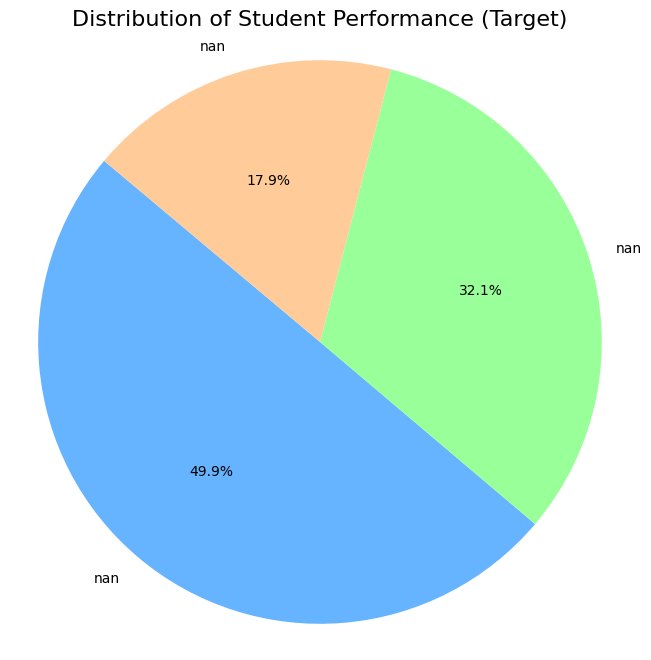

In [97]:
import matplotlib.pyplot as plt

# Get the value counts of the 'Target' column
target_counts = df['Target'].value_counts()

# Map the encoded numbers back to their original labels for better readability on the chart
# Assuming le (LabelEncoder) is still available and holds the original classes.
# If le is not available, these mappings would need to be manually defined or inferred.

# Retrieve the original labels from the LabelEncoder
original_labels = list(le.classes_)

# Create a mapping from encoded number to original label
label_mapping = {i: label for i, label in enumerate(original_labels)}

# Apply this mapping to the index of target_counts for chart labels
target_counts.index = target_counts.index.map(label_mapping)


plt.figure(figsize=(8, 8))
plt.pie(target_counts, labels=target_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ffcc99'])
plt.title('Distribution of Student Performance (Target)', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Evaluate using cross validation

**Evaluation**

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

Importing evaluation metrics

In [88]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Train a model

In [89]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average='weighted')

recall = recall_score(y_test, y_pred, average='weighted')

f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7491525423728813
Precision: 0.7302662304622298
Recall: 0.7491525423728813
F1 Score: 0.7317325196418032


Calculating metrics

# Task
Visualize model accuracies using a bar chart and summarize the findings from the model evaluation, highlighting the best-performing model and any insights gained.

## Visualize Model Accuracies

### Subtask:
Generate a bar chart to visually compare the accuracy scores of the different machine learning models obtained from cross-validation. This will help identify the best-performing model.


**Reasoning**:
To visualize the model accuracies, I will create a bar plot using `seaborn.barplot` based on the `results_df` DataFrame. This plot will compare the accuracy scores of the different models, making it easy to identify the best performer.



/tmp/ipykernel_431/3622973873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')


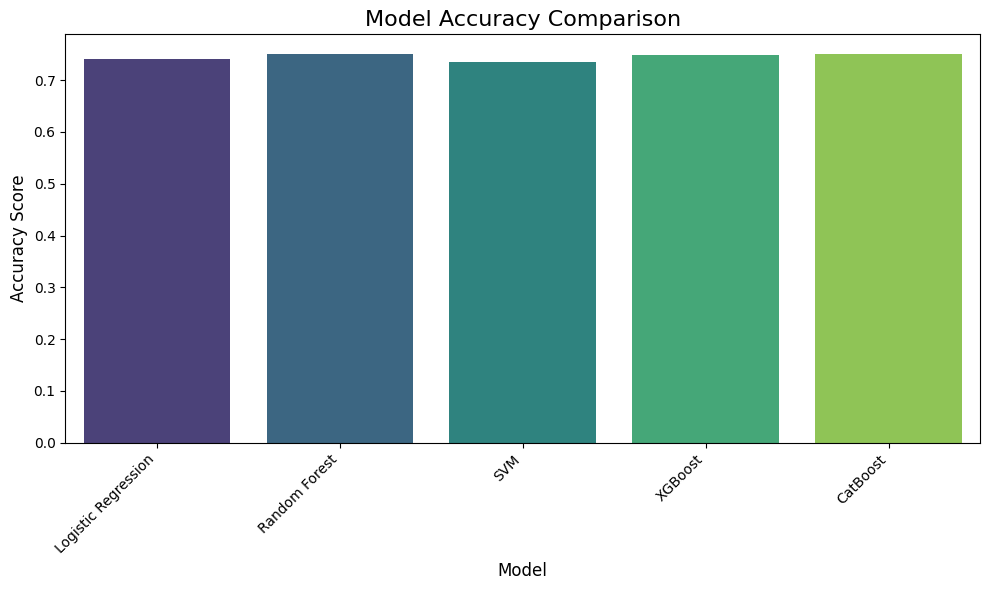

In [95]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` due to `palette` being used without `hue`. To address this, I will explicitly set `hue='Model'` and `legend=False` in `sns.barplot` to ensure correct usage and suppress the warning.



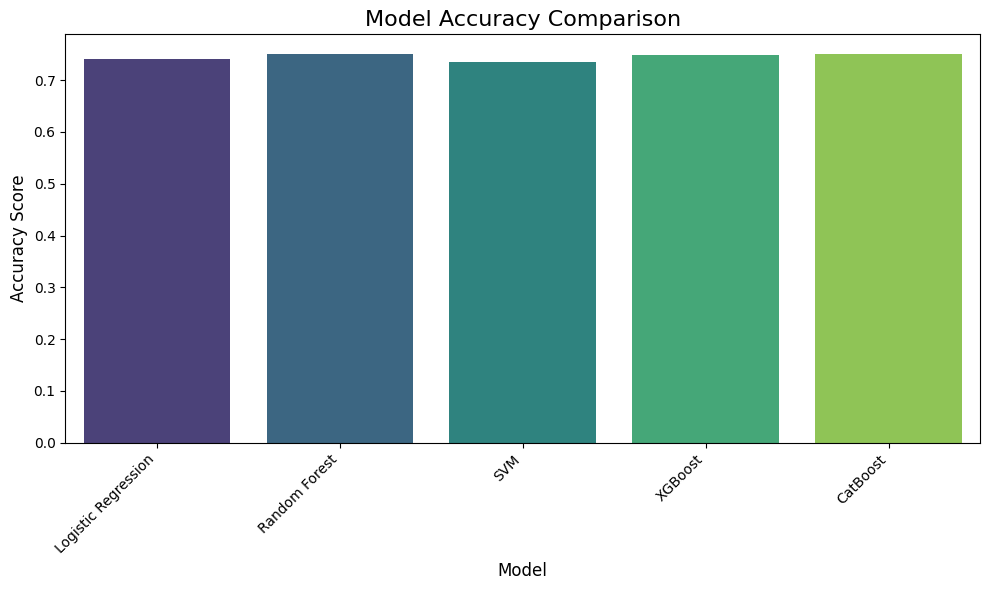

In [96]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Model Evaluation Summary

The bar chart above visually represents the cross-validation accuracy scores for each machine learning model. Based on the `results_df` and the plot, we can observe the following:

*   **Random Forest** achieved the highest accuracy score of approximately 0.7509.
*   **CatBoost** followed closely with an accuracy of approximately 0.7507.
*   **XGBoost** also performed well, with an accuracy around 0.7477.
*   **Logistic Regression** and **SVM** showed slightly lower accuracies, approximately 0.7403 and 0.7344, respectively.

From this evaluation, **Random Forest** appears to be the best-performing model for this dataset based on cross-validation accuracy. The differences in accuracy between Random Forest, CatBoost, and XGBoost are quite small, suggesting that all three ensemble methods are strong contenders. Further fine-tuning and evaluation using other metrics might reveal more nuanced differences.

## Summary:

### Data Analysis Key Findings

*   The Random Forest model achieved the highest accuracy, with a score of approximately 0.7509.
*   CatBoost closely followed with an accuracy of approximately 0.7507.
*   XGBoost also performed well, recording an accuracy of about 0.7477.
*   Logistic Regression and SVM showed slightly lower accuracies, approximately 0.7403 and 0.7344, respectively.
*   A bar chart was successfully generated to visually compare these accuracy scores, clearly showing the performance hierarchy among the models.

### Insights or Next Steps

*   While Random Forest was the top performer based on accuracy, the marginal differences between Random Forest, CatBoost, and XGBoost suggest that all three ensemble methods are strong candidates.
*   Further fine-tuning of these top-performing models and evaluating them using additional metrics beyond accuracy would provide a more comprehensive understanding of their performance and robustness.
